# Кейс 1: Рекомендации банковских продуктов  
**Цель:** Предсказать, какие товары предложить пользователю интернет-магазина.  
**Основные задачи:** Анализ событий и характеристик товаров, выбор метрик, построение модели рекомендаций, внедрение модели в виде веб-сервиса, мониторинг и обновление модели.  

## Описание:  
Имеется набор данных по клиентам банка, где на ряд дат 2015 года приведены основных характеристики килентов и приведён перечень банковских продуктов, которыми они обладают. Необхоидмо создать рекомендательную систему, которая будет рекомендовать клиентам банка продукты, которые могут быть их интересными. В качестве верификации будут использоваться данные из 2016, приведённые в том же файле.  

Мы обучим модель, и на основании неё сделаем микросервис, который будет запускаться из docker-контейнера, давать предсказания по curl-запросу, и вся его деятельность будет логироваться в prometheus, при желании можно будет пронаблюдать дэшборды через graphana.  

## Инструментарий:  
- MLFlow - как среда для моделирования и логирования  
- featuretools - для создания синтетических признаков  
- ALS и sklearn - для двухуровневой рекомендательной системы  
- optuna - для оптимизации гиперпараметров модели  


## Постановка задачи и целевая переменная

Модель предсказывает, **какой продукт клиент купит в 2016 году**, — целевая переменная
`purchase` равна коду первого купленного продукта из шорт-листа, `0` — если покупок не было,
`other` — если первым куплен редкий продукт.

Шорт-лист — это продукты, на которые в 2015 году пришлось не меньше 1% покупок:
у большинства из 24 продуктов доля клиентов меньше 0.5% (см. `eda.ipynb`), поэтому
моделировать все продукты сразу нельзя — получаются классы с одним-двумя объектами.
Правило шорт-листа и его состав печатаются в разделе «Целевая переменная» ниже и попадают
в `fastapi/preprocessing_params.json`.

In [1]:
# Стандартная библиотека
import gc
import json
import logging
import os
import warnings

# Сторонние библиотеки
from dotenv import load_dotenv
import featuretools as ft
from implicit.als import AlternatingLeastSquares
import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import optuna
import pandas as pd
import scipy
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import tqdm
import woodwork

c:\Users\Admin\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
gc.collect()

0

In [3]:
# Датасет скачивается из соревнования Kaggle ноутбуком loader.ipynb
df = pd.read_csv('data/train_ver2.csv')
df


C:\Users\Admin\AppData\Local\Temp\ipykernel_15840\2741283767.py:2: DtypeWarning: Columns (5,8,11,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/train_ver2.csv')


,fecha_dato,ncodpers,ind_empleado,pais_residencia,sexo,age,fecha_alta,ind_nuevo,antiguedad,indrel,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
0,2015-01-28,1375586,N,ES,H,35,2015-01-12,0.0,6,1.0,...,0,0,0,0,0,0,0,0.0,0.0,0
1,2015-01-28,1050611,N,ES,V,23,2012-08-10,0.0,35,1.0,...,0,0,0,0,0,0,0,0.0,0.0,0
2,2015-01-28,1050612,N,ES,V,23,2012-08-10,0.0,35,1.0,...,0,0,0,0,0,0,0,0.0,0.0,0
3,2015-01-28,1050613,N,ES,H,22,2012-08-10,0.0,35,1.0,...,0,0,0,0,0,0,0,0.0,0.0,0
4,2015-01-28,1050614,N,ES,V,23,2012-08-10,0.0,35,1.0,...,0,0,0,0,0,0,0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13647304,2016-05-28,1166765,N,ES,V,22,2013-08-14,0.0,33,1.0,...,0,0,0,0,0,0,0,0.0,0.0,0
13647305,2016-05-28,1166764,N,ES,V,23,2013-08-14,0.0,33,1.0,...,0,0,0,0,0,0,0,0.0,0.0,0
13647306,2016-05-28,1166763,N,ES,H,47,2013-08-14,0.0,33,1.0,...,0,0,0,0,0,0,0,0.0,0.0,0
13647307,2016-05-28,1166789,N,ES,H,22,2013-08-14,0.0,33,1.0,...,0,0,0,0,0,0,0,0.0,0.0,0


In [4]:
with open('columns.txt', 'r', encoding='utf-8') as file:
    content = file.read().strip()  # Читаем содержимое и удаляем пробелы по краям
    items = [item.strip() for item in content.split(';') if item.strip()]

In [5]:
cool_names_dict = dict(zip(list(df.columns),items))

In [6]:
cool_names_dict

{'fecha_dato': 'Колонка для разделения таблицы',
 'ncodpers': 'Идентификатор пользователя',
 'ind_empleado': 'Статус занятости работника',
 'pais_residencia': 'Страна резидентства',
 'sexo': 'Пол',
 'age': 'Возраст',
 'fecha_alta': 'Дата первого договора',
 'ind_nuevo': 'Новый клиент (<6m)',
 'antiguedad': 'Стаж клиента (в месяцах)',
 'indrel': 'первичный клиент',
 'ult_fec_cli_1t': 'Последняя дата премиума',
 'indrel_1mes': 'Клиентский сегмент',
 'tiprel_1mes': 'Статус клиента (действующий, бывший, пр)',
 'indresi': 'Соотечественник',
 'indext': 'Чужак',
 'conyuemp': 'супруг(а) работника',
 'canal_entrada': 'Канал',
 'indfall': 'Индекс актуальности счёта',
 'tipodom': 'Тип адреса',
 'cod_prov': 'Код провинции',
 'nomprov': 'Имя провинции',
 'ind_actividad_cliente': 'Активность пользователя',
 'renta': 'Доход домохозяйства',
 'segmento': 'VIP-статус',
 'ind_ahor_fin_ult1': 'Сберегательный счёт',
 'ind_aval_fin_ult1': 'Банковская гарантия',
 'ind_cco_fin_ult1': 'Текущие счета',
 'ind_cd

In [7]:
products=['ind_ahor_fin_ult1',
'ind_aval_fin_ult1',
'ind_cco_fin_ult1',
'ind_cder_fin_ult1',
'ind_cno_fin_ult1',
'ind_ctju_fin_ult1',
'ind_ctma_fin_ult1',
'ind_ctop_fin_ult1',
'ind_ctpp_fin_ult1',
'ind_deco_fin_ult1',
'ind_deme_fin_ult1',
'ind_dela_fin_ult1',
'ind_ecue_fin_ult1',
'ind_fond_fin_ult1',
'ind_hip_fin_ult1',
'ind_plan_fin_ult1',
'ind_pres_fin_ult1',
'ind_reca_fin_ult1',
'ind_tjcr_fin_ult1',
'ind_valo_fin_ult1',
'ind_viv_fin_ult1',
'ind_nomina_ult1',
'ind_nom_pens_ult1',
'ind_recibo_ult1']

In [8]:
# удаляем столбцы где слишком много пропусков
df = df.drop(['indrel','indext'],axis=1) 

In [9]:
# преобразуем столбцы в числовые типы данных
quantitative_cols = ['age','antiguedad','renta']
for col in quantitative_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [10]:
# заменяем аномальное значение в antiguedad на NaN
df['antiguedad']=df['antiguedad'].replace(np.float64(-999999.0),np.nan)

In [11]:
# Пропуски числовых признаков — медианами, категориальных — модой.
# Значения сохраняем: они уедут в fastapi/preprocessing_params.json и будут использоваться
# сервисом, чтобы предобработка на проде совпадала с обучением (CODE_REVIEW §P1.10).
medians = {col: float(df[col].median()) for col in ['age', 'antiguedad', 'renta']}
for col, value in medians.items():
    df[col] = df[col].fillna(value)

cats = [x for x in list(df.columns) if x not in ['age', 'antiguedad', 'fecha_dato', 'ncodpers', 'renta']]
modes = {col: df[col].mode()[0] for col in cats}
for col, value in modes.items():
    df[col] = df[col].fillna(value)

print('Медианы:', medians)
print(f'Мод сохранено: {len(modes)}')


Медианы: {'age': 39.0, 'antiguedad': 50.0, 'renta': 101850.0}
Мод сохранено: 41


In [12]:
# Разделяем возраст на возрастные группы
def calculate_age_intervals(df, n_intervals=3):
    # Группируем по возрасту и агрегируем продукты
    age_groups = df.groupby('age', observed=True)['total_products'].sum().reset_index()
    age_groups = age_groups.sort_values('age')
    
    # Вычисляем кумулятивную сумму на сгруппированных данных
    cum_products = np.cumsum(age_groups['total_products'].values)
    total = cum_products[-1]
    step = total / n_intervals
    
    # Находим границы интервалов через векторные операции
    targets = np.arange(1, n_intervals) * step
    idxs = np.searchsorted(cum_products, targets, side='right')
    upper_ages = age_groups['age'].values[np.minimum(idxs, len(age_groups)-1)]
    
    # Формируем интервалы
    intervals = []
    lower = age_groups['age'].iloc[0]
    for upper in upper_ages:
        intervals.append((lower, upper))
        lower = upper + 1
    intervals.append((lower, age_groups['age'].iloc[-1]))
    
    return intervals

# Расчет продуктов и интервалов
# age_intervals — параметр предобработки: те же границы использует сервис
df['total_products'] = df[products].sum(axis=1)
age_intervals = calculate_age_intervals(df, 9)
print(f"Возрастные интервалы: {[tuple(map(int, i)) for i in age_intervals]}")


Возрастные интервалы: [(2, 23), (24, 28), (29, 36), (37, 41), (42, 45), (46, 49), (50, 54), (55, 63), (64, 164)]


C:\Users\Admin\AppData\Local\Temp\ipykernel_15840\4101436456.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df.groupby('age_interval')['total_products'].mean().reset_index()


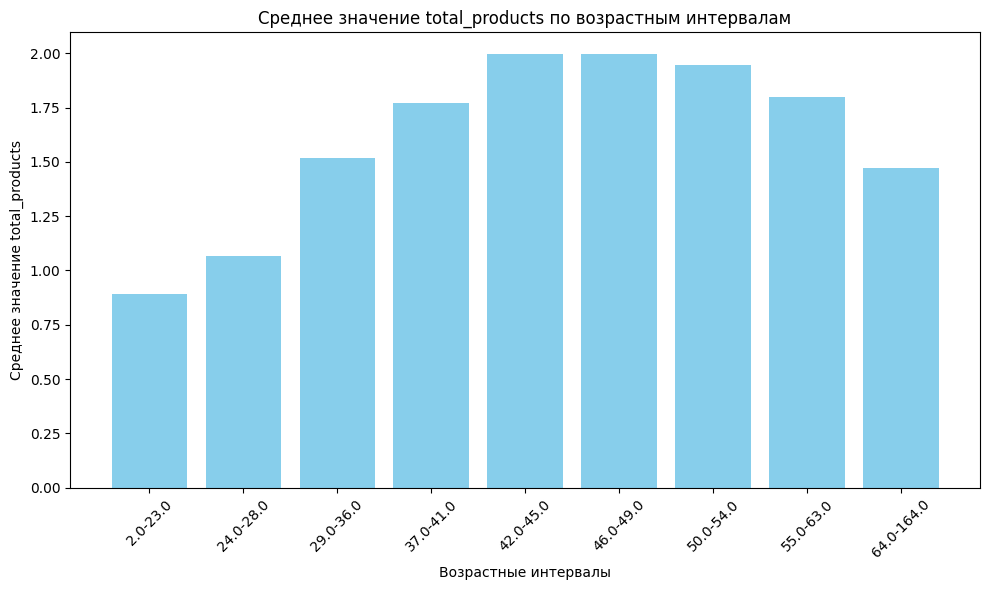

In [13]:
# Создаем столбец с интервалами возраста
df['age_interval'] = pd.cut(df['age'], bins=[interval[0] for interval in age_intervals] + [age_intervals[-1][1]],
                            labels=[f"{interval[0]}-{interval[1]}" for interval in age_intervals])

# Группируем данные по интервалам возраста и вычисляем среднее значение total_products для каждого интервала
grouped_data = df.groupby('age_interval')['total_products'].mean().reset_index()

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(grouped_data['age_interval'], grouped_data['total_products'], color='skyblue')
plt.xlabel('Возрастные интервалы')
plt.ylabel('Среднее значение total_products')
plt.title('Среднее значение total_products по возрастным интервалам')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [14]:
def create_time_cohorts(series, max_cohorts=30):
    """Возвращает (метки когорт, спецификация когорт для сервиса).

    Спецификация описывает границы когорт в днях от base_date, чтобы сервис
    применял ровно те же интервалы, что и обучение (CODE_REVIEW §2.2, §P1.10):
    интервал i покрывает (left_days, right_days], где left_days — правый день
    предыдущего бина, right_days — максимальный день бина.
    """
    series_dt = pd.to_datetime(series)
    base_date = series_dt.min().normalize()
    
    # Вычисляем дни относительно базовой даты
    days = (series_dt.dt.normalize() - base_date).dt.days
    
    # Определяем оптимальное количество когорт
    unique_days = days.unique()
    n_cohorts = min(max_cohorts, len(unique_days))
    
    # Создаем интервалы через qcut (быстрее чем apply)
    try:
        qbins = pd.qcut(days, q=n_cohorts, precision=0, duplicates='drop')
    except ValueError:
        return series_dt.dt.strftime('%Y-%m-%d').astype('str'), {'mode': 'raw'}
    
    # Генерируем строковые метки для всех интервалов сразу
    interval_labels = [
        f"{(base_date + pd.Timedelta(days=int(iv.left))).strftime('%Y-%m-%d')}"
        f" – {(base_date + pd.Timedelta(days=int(iv.right))).strftime('%Y-%m-%d')}"
        for iv in qbins.cat.categories
    ]
    
    # Маппинг категорий на строки через векторные операции
    label_map = dict(zip(qbins.cat.categories, interval_labels))
    cohort_labels = qbins.cat.rename_categories(label_map).astype('str')
    
    # Границы для сервиса берем по фактическому распределению дней по бинам:
    # так спецификация воспроизводит обучающие метки один в один
    codes = qbins.cat.codes.to_numpy()
    days_np = days.to_numpy()
    rights = [int(days_np[codes == i].max()) for i in range(len(interval_labels))]
    lefts = [int(days_np[codes == 0].min()) - 1] + rights[:-1]
    missing_label = str(cohort_labels[days.isna()].iloc[0]) if days.isna().any() else 'unknown'
    spec = {
        'mode': 'intervals',
        'base_date': base_date.strftime('%Y-%m-%d'),
        'closed': 'right',
        'missing_label': missing_label,
        'intervals': [
            {'left_days': left, 'right_days': right, 'label': label}
            for left, right, label in zip(lefts, rights, interval_labels)
        ],
    }
    
    return cohort_labels, spec


def map_date_by_cohort(value, spec):
    """Логика сервиса (app1.map_date_to_cohort) — проверяем, что спецификация её воспроизводит."""
    base_date = pd.Timestamp(spec['base_date']).normalize()
    parsed = pd.to_datetime(value, errors='coerce')
    if pd.isna(parsed):
        return spec.get('missing_label', 'unknown')
    days = int((parsed.normalize() - base_date).days)
    for interval in spec['intervals']:
        if interval['left_days'] < days <= interval['right_days']:
            return interval['label']
    return 'unknown'


In [15]:
date_cohorts = {}
for time_col in ['fecha_alta', 'ult_fec_cli_1t']:
    raw_dates = df[time_col].copy()
    cohorts, spec = create_time_cohorts(raw_dates, max_cohorts=12)
    df[time_col] = cohorts
    date_cohorts[time_col] = spec
    if spec.get('mode') == 'intervals':
        # проверяем, что сервисная логика по этой спецификации выдает те же метки
        restored = raw_dates.map(lambda value, spec=spec: map_date_by_cohort(value, spec))
        mismatch = int((restored != cohorts).sum())
        print(f'{time_col}: когорт {len(spec["intervals"])}, расхождений с обучением: {mismatch}')
        if mismatch:
            print(f'ВНИМАНИЕ: спецификация когорт {time_col} не воспроизводит {mismatch} значений')
    else:
        print(f'{time_col}: qcut не построил когорты, колонка осталась строкой с датой')


fecha_alta: когорт 12, расхождений с обучением: 0


KeyboardInterrupt: 

In [ ]:
# Определяем порог для редких значений
threshold = 0.01

# Сворачиваем редкие категории в 'other' и запоминаем ровно то, что свернули:
# этот же словарь уезжает в сервис, поэтому предобработка на проде не расходится
# с обучением (CODE_REVIEW §P1.10, §4.4).
replacer = {}
# Продукты из сворачивания исключаем явно, а не позицией в списке колонок (CODE_REVIEW §4.2)
non_product_cats = [col for col in cats if col not in products]
for col in non_product_cats:
    df[col] = df[col].astype(str)
    # Вычисляем частоты значений (уже без интервальных типов)
    value_counts = df[col].value_counts(normalize=True)
    
    # Получаем редкие значения
    rare_values = value_counts[value_counts < threshold].index
    
    # Запоминаем соответствие и сворачиваем в 'other'
    replacer[col] = {value: 'other' for value in rare_values}
    df.loc[df[col].isin(rare_values), col] = 'other'
    
    print(cool_names_dict[col], ':', df[col].nunique(), 'categories')


In [ ]:
def json_converter(obj):
    """Конвертер numpy/pandas-типов в JSON для артефактов сервиса."""
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, pd.Timestamp):
        return obj.strftime('%Y-%m-%d')
    if isinstance(obj, pd.Interval):
        return [float(obj.left), float(obj.right)]
    raise TypeError(f"Object of type {obj.__class__.__name__} is not JSON serializable")


def save_json(path, payload):
    """Сохраняет артефакт предобработки для микросервиса."""
    with open(path, 'w', encoding='utf-8') as file:
        json.dump(payload, file, indent=2, ensure_ascii=False, default=json_converter)
    print(f'Сохранено: {path}')


save_json('fastapi/replacer.json', replacer)


In [ ]:
df = df.drop(columns=['nomprov','tipodom'], axis=1)

In [ ]:
def clip_outliers_by_quantile(df: pd.DataFrame, 
                             column: str, 
                             lower_quantile: float = 0.01,
                             upper_quantile: float = 0.99) -> pd.DataFrame:
    """
    Заменяет выбросы в указанном столбце на граничные значения квантилей
    
    Параметры:
        df - исходный DataFrame
        column - имя столбца для обработки
        lower_quantile - нижний квантиль (по умолчанию 1%)
        upper_quantile - верхний квантиль (по умолчанию 99%)
    
    Возвращает:
        Модифицированный DataFrame
    """
    # Создаем копию DataFrame чтобы не менять исходные данные
    df = df.copy()
    
   
    # Вычисляем границы
    lower_bound = df[column].quantile(lower_quantile)
    upper_bound = df[column].quantile(upper_quantile)
    
    # Замена выбросов (с логированием изменений)
    n_outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    print(f"Обнаружено выбросов в столбце {column}: {n_outliers} ({n_outliers/len(df):.1%})")
    
    # Применяем "отсечение" значений
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    
    return df


Обнаружено выбросов в столбце renta: 682296 (5.0%)
Обнаружено выбросов в столбце antiguedad: 672509 (4.9%)


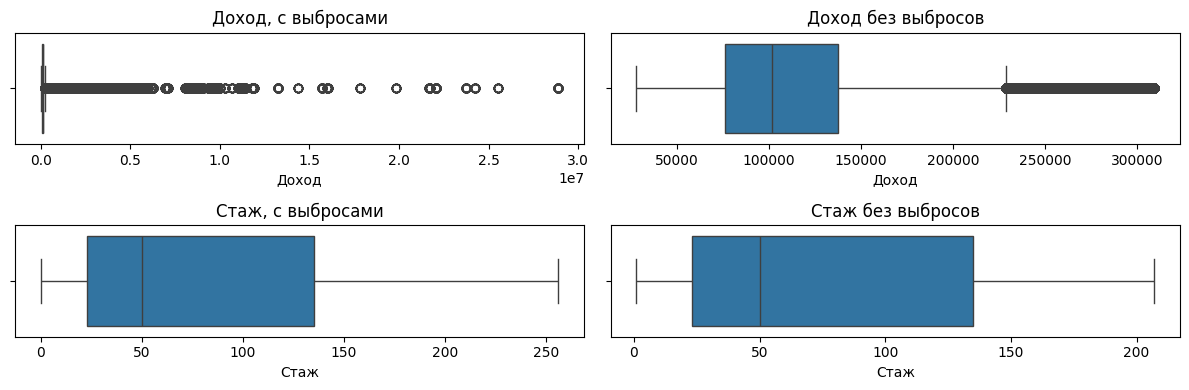

In [ ]:
a = df[['renta','antiguedad']].copy()
fig, ax = plt.subplots(2,2, figsize=(12,4))

for axi, col in enumerate(a.columns):
    # Левая колонка - с выбросами
    sns.boxplot(x=col, data=a, ax=ax[axi, 0])
    ax[axi, 0].set_title('Доход, с выбросами' if col == 'renta' else 'Стаж, с выбросами')
    ax[axi, 0].set_xlabel('Доход' if col == 'renta' else 'Стаж')
    
    # Правая колонка - без выбросов
    b = clip_outliers_by_quantile(a, col, 0.01, 0.96)
    sns.boxplot(x=col, data=b, ax=ax[axi, 1])
    ax[axi, 1].set_title('Доход без выбросов' if col == 'renta' else 'Стаж без выбросов')
    ax[axi, 1].set_xlabel('Доход' if col == 'renta' else 'Стаж')

plt.tight_layout()
plt.show()

In [ ]:
clip_bounds = {}
for column in ['renta', 'antiguedad']:
# Вычисляем границы
    lower_bound = df[column].quantile(0.01)
    upper_bound = df[column].quantile(0.96)
    
    # Замена выбросов (с логированием изменений)
    n_outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    print(f"Обнаружено выбросов в столбце {column}: {n_outliers} ({n_outliers/len(df):.1%})")
    
    # Применяем "отсечение" значений
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    clip_bounds[column] = [float(lower_bound), float(upper_bound)]

print('Границы клиппинга:', clip_bounds)


# Персональные
Рассчитаем персональные рекомендации.

In [ ]:
# Целевая переменная строится по всем 24 продуктам, а не по первым трём (CODE_REVIEW §3.1).
# События покупок: продукт появился у клиента впервые (было 0 -> стало 1).
df_sorted = df.sort_values(['ncodpers', 'fecha_dato'])

# Кодируем клиентов и продукты в числовые индексы
users = list(df['ncodpers'].unique())
user_map = {int(user): idx for idx, user in enumerate(users)}
product_map = {product: idx for idx, product in enumerate(products)}

# Предыдущее состояние продукта у клиента — одним groupby на все продукты сразу
products_prev = df_sorted.groupby('ncodpers')[products].shift(1).fillna(0)
current = df_sorted[products].fillna(0).to_numpy(dtype='int8')
previous = products_prev.to_numpy(dtype='int8')
new_purchase = (current == 1) & (previous == 0)

rows, cols = np.nonzero(new_purchase)
events = pd.DataFrame({
    'ncodpers': df_sorted['ncodpers'].to_numpy()[rows],
    'fecha_dato': df_sorted['fecha_dato'].to_numpy()[rows],
    'purchase': (cols + 1).astype(int),  # код продукта = позиция в products + 1
})
print(f'Всего событий покупок: {len(events):,}')
print(events.head())

# Шорт-лист целевых продуктов: берем продукты, на которые пришлось не меньше
# MIN_PURCHASE_SHARE покупок 2015 года (обучающий период, без подглядывания в 2016-й).
# Осознанное сужение задачи: остальные продукты встречаются слишком редко,
# чтобы обучить на них устойчивый класс (CODE_REVIEW §P1.8).
MIN_PURCHASE_SHARE = 0.01   # порог по доле покупок 2015 года
MAX_TARGET_PRODUCTS = 12    # ограничение на размер шорт-листа (размерность классов)
OTHER_CLASS = 99

train_purchases = events[events['fecha_dato'] <= '2016-01-01']
purchase_share = train_purchases['purchase'].value_counts(normalize=True)
candidates = purchase_share[purchase_share >= MIN_PURCHASE_SHARE]
target_codes = sorted(int(code) for code in candidates.index[:MAX_TARGET_PRODUCTS])
dropped_by_cap = [int(code) for code in candidates.index[MAX_TARGET_PRODUCTS:]]

label_map = {0: 'no_purchase'}
label_map.update({code: products[code - 1] for code in target_codes})
label_map[OTHER_CLASS] = 'other'

print(f'Продуктов всего: {len(products)}; прошли порог {MIN_PURCHASE_SHARE:.0%}: {len(candidates)}; '
      f'в шорт-листе: {len(target_codes)}')
for code in target_codes:
    print(f'  {code:>2} = {products[code - 1]:<22} доля покупок 2015: {purchase_share[code]:.2%}')
if dropped_by_cap:
    print(f'Отброшено ограничением MAX_TARGET_PRODUCTS={MAX_TARGET_PRODUCTS}: '
          f'{[products[code - 1] for code in dropped_by_cap]}')
print(f'Класс {OTHER_CLASS} = other: {1 - purchase_share[target_codes].sum():.2%} покупок 2015 '
      f'приходится на продукты вне шорт-листа')
print('label_map:', label_map)


In [ ]:
common_train = events[events['fecha_dato']<='2016-01-01'].copy()
common_test = events[events['fecha_dato']>'2016-01-01'].copy()

In [ ]:
# создаём sparse-матрицу формата CSR 
user_item_matrix_train = scipy.sparse.csr_matrix((
    np.ones(len(common_train)),
    (common_train['ncodpers'].to_numpy(), common_train['purchase'].to_numpy())),
    dtype=np.int8)

In [ ]:
als_model = AlternatingLeastSquares(factors=50, iterations=50, regularization=0.05, random_state=0)
als_model.fit(user_item_matrix_train) 

c:\Users\Admin\miniconda3\Lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: OpenBLAS is configured to use 20 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 50/50 [01:01<00:00,  1.23s/it]


In [ ]:
def get_recommendations_als(user_item_matrix, model, user_id, user_map, product_map, include_seen=True, n=5):
    """Возвращает отранжированные ALS-рекомендации для заданного пользователя."""
    # Получаем закодированный user_id
    user_id_enc = user_map[user_id]
    
    # Создаем обратный словарь для product_map
    inv_product_map = {v: k for k, v in product_map.items()}
    
    # Получаем рекомендации от модели
    indices, scores = model.recommend(
        user_id_enc,
        user_item_matrix[user_id_enc],
        filter_already_liked_items=not include_seen,
        N=n
    )
    
    # Создаем итоговый DataFrame в pandas (polars в проекте не используется)
    return pd.DataFrame({
        'product': [inv_product_map.get(int(index)) for index in indices],
        'score': scores
    })


In [ ]:
common_users = [user for user in common_train['ncodpers'].unique() if user in common_test['ncodpers'].unique()]
# получаем список всех возможных user_id (перекодированных) для которых можно посчитать персональные рекомендации на основании матрицы схожести
user_ids_encoded = [user_map[int(x)] for x in common_users]

# получаем рекомендации для всех пользователей
als_recommendations = als_model.recommend(
    user_ids_encoded, 
    user_item_matrix_train[user_ids_encoded], 
    filter_already_liked_items=True, N=1)

In [ ]:
# преобразуем полученные рекомендации в табличный формат
item_ids_enc = als_recommendations[0]
als_scores = als_recommendations[1]

als_recommendations = pd.DataFrame({
    "user_id_enc": user_ids_encoded,
    "item_id_enc": item_ids_enc.tolist(), 
    "score": als_scores.tolist()})

In [ ]:
# Разворачиваем (exploding) столбцы item_id_enc и score в отдельные строки для каждого элемента списка
# ignore_index=True позволяет сбросить индекс результирующего DataFrame, чтобы индексы были последовательными
als_recommendations = als_recommendations.explode(["item_id_enc", "score"], ignore_index=True)
als_recommendations

,user_id_enc,item_id_enc,score
0,416956,0,0.0
1,417008,2,0.000044
2,417012,0,0.0
3,416985,0,0.0
4,416987,2,0.000088
...,...,...,...
10006,924022,2,0.000002
10007,924018,0,0.0
10008,923901,2,0.000045
10009,923534,0,0.0


In [ ]:
# приводим типы данных
als_recommendations["item_id_enc"] = als_recommendations["item_id_enc"].astype("int")
als_recommendations["score"] = als_recommendations["score"].astype("float")
inv_product_map = {v: k for k, v in product_map.items()}
inv_user_map = {v: k for k, v in user_map.items()}
# получаем изначальные идентификаторы
als_recommendations["ncodpers"] =als_recommendations["user_id_enc"].map(inv_user_map)
als_recommendations["product"] = als_recommendations["item_id_enc"].map(inv_product_map)
als_recommendations = als_recommendations.drop(columns=["user_id_enc", "item_id_enc"])
als_recommendations

,score,ncodpers,product
0,0.000000,15927,ind_ahor_fin_ult1
1,0.000044,15944,ind_cco_fin_ult1
2,0.000000,15950,ind_ahor_fin_ult1
3,0.000000,15965,ind_ahor_fin_ult1
4,0.000088,15969,ind_cco_fin_ult1
...,...,...,...
10006,0.000002,1519894,ind_cco_fin_ult1
10007,0.000000,1519912,ind_ahor_fin_ult1
10008,0.000045,1519950,ind_cco_fin_ult1
10009,0.000000,1520012,ind_ahor_fin_ult1


In [ ]:

common_users_list = [int(x) for x in common_users]

In [ ]:
mask = common_test['ncodpers'].isin(common_users_list)
filtered_events_test = common_test[common_test['ncodpers'].isin(common_users_list)]
filtered_events_test

,ncodpers,fecha_dato,purchase
28,15927,2016-03-28,3
41,15944,2016-03-28,3
45,15950,2016-04-28,3
56,15965,2016-03-28,3
59,15969,2016-04-28,3
...,...,...,...
636405,1519912,2016-02-28,3
636427,1519950,2016-03-28,3
636464,1520012,2016-02-28,3
636465,1520012,2016-04-28,3


In [ ]:
recommended_products_list=[]
user_ids_list=[]
non_common_users = list(filtered_events_test['ncodpers'].unique())
for user in non_common_users:
    user_ids_list.extend([user])
    recommended_products_list.append(np.nan)
recommended_tracks_df = pd.DataFrame({'ncodpers': user_ids_list, 'product': recommended_products_list})
recommended_tracks_df = pd.concat([recommended_tracks_df, als_recommendations[['ncodpers', 'product']]], axis=0)
recommended_tracks_df.rename(columns={'product': 'recommended_product_id'}, inplace=True)
recommended_tracks_df.set_index('ncodpers').to_parquet('fastapi/personal_als.parquet')

### Качество ALS: precision@k / recall@k

Раньше ALS использовался только как источник признака `recommended_product_id`, и качество
самих рекомендаций нигде не измерялось (CODE_REVIEW §3.7). Считаем precision@k / recall@k
на отложенном периоде 2016 года: рекомендации строятся по истории 2015 года, релевантными
считаются продукты, которые клиент действительно купил в 2016 году.


In [ ]:
# --- Оценка качества ALS на отложенном периоде (CODE_REVIEW §P1.11) ---
K = 5

als_top_k = als_model.recommend(
    user_ids_encoded,
    user_item_matrix_train[user_ids_encoded],
    filter_already_liked_items=True,
    N=K
)

recommendations_df = pd.DataFrame({
    'ncodpers': [inv_user_map[user_id] for user_id in user_ids_encoded],
    'recommended': [[products[int(index)] for index in items] for items in als_top_k[0]],
})

# Релевантные продукты: все покупки клиента в 2016 году
relevant_by_user = (
    common_test[common_test['ncodpers'].isin(common_users_list)]
    .groupby('ncodpers')['purchase']
    .apply(lambda codes: {products[int(code) - 1] for code in codes})
)
recommendations_df['relevant'] = (
    recommendations_df['ncodpers'].map(relevant_by_user)
    .apply(lambda items: items if isinstance(items, set) else set())
)
recommendations_df['hits'] = [
    len(set(recommended) & relevant)
    for recommended, relevant in zip(recommendations_df['recommended'], recommendations_df['relevant'])
]
recommendations_df['relevant_size'] = recommendations_df['relevant'].apply(len)

# precision@k — доля попаданий среди k рекомендаций, recall@k — по клиентам,
# у которых в 2016 году была хотя бы одна покупка
als_precision_at_k = float((recommendations_df['hits'] / K).mean())
users_with_purchases = recommendations_df['relevant_size'] > 0
als_recall_at_k = float(
    (recommendations_df.loc[users_with_purchases, 'hits']
     / recommendations_df.loc[users_with_purchases, 'relevant_size']).mean()
)
als_hit_rate = float((recommendations_df['hits'] > 0).mean())

als_metrics = pd.DataFrame({
    'k': [K],
    'users': [len(recommendations_df)],
    'precision_at_k': [als_precision_at_k],
    'recall_at_k': [als_recall_at_k],
    'hit_rate': [als_hit_rate],
    'relevant_per_user': [float(recommendations_df['relevant_size'].mean())],
})
als_metrics.to_csv('als_metrics.csv', index=False)
print(als_metrics.to_string(index=False))
print()
print(f"Бейзлайн: у {users_with_purchases.mean():.2%} клиентов в 2016 году была хотя бы одна покупка")
print('precision@k ALS сравниваем с этим бейзлайном и с качеством классификатора')


In [ ]:
recommended_tracks_df

,ncodpers,recommended_product_id
0,15927,NaN
1,15944,NaN
2,15950,NaN
3,15965,NaN
4,15969,NaN
...,...,...
10006,1519894,ind_cco_fin_ult1
10007,1519912,ind_ahor_fin_ult1
10008,1519950,ind_cco_fin_ult1
10009,1520012,ind_ahor_fin_ult1


# Теперь делаем рекомендации на основе данных о клиенте

In [ ]:
# Преобразуем колонку fecha_dato в формат datetime
df['fecha_dato'] = pd.to_datetime(df['fecha_dato'])

In [ ]:
#supress warings
warnings.filterwarnings('ignore')

In [ ]:
# Фильтрация данных за 2015 год
df2015 = df[df['fecha_dato'] <= '2015-12-31']

# Получаем индексы последних записей для каждого клиента
last_idx = df2015.groupby('ncodpers')['fecha_dato'].idxmax()

# Собираем финальный датасет за один проход
train_df = (
    df2015.loc[last_idx]
    .drop(['fecha_dato', 'age', 'fecha_alta'], axis=1)
    .reset_index(drop=True)
)

train_df.head()

,ncodpers,ind_empleado,pais_residencia,sexo,ind_nuevo,antiguedad,ult_fec_cli_1t,indrel_1mes,tiprel_1mes,indresi,...,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1,total_products,age_interval
0,15889,other,ES,V,0.0,207.0,2015-06-30 – 2015-12-24,1,A,S,...,0,0,1,1,0,0.0,0.0,0,4.0,55.0-63.0
1,15890,other,ES,V,0.0,207.0,2015-06-30 – 2015-12-24,1,A,S,...,0,0,1,0,0,1.0,1.0,1,8.0,55.0-63.0
2,15891,N,ES,H,0.0,207.0,2015-06-30 – 2015-12-24,1.0,A,S,...,0,0,0,0,0,0.0,0.0,0,0.0,55.0-63.0
3,15892,other,ES,H,0.0,207.0,2015-06-30 – 2015-12-24,1,A,S,...,0,1,1,1,0,0.0,0.0,1,7.0,55.0-63.0
4,15893,N,ES,V,0.0,207.0,2015-06-30 – 2015-12-24,1,A,S,...,0,0,0,1,0,0.0,0.0,0,1.0,55.0-63.0


In [ ]:
train_df.to_csv('data/train_final.csv', index=False)

In [ ]:
first_buy = filtered_events_test.groupby('ncodpers')['fecha_dato'].idxmin()
first_buy_df = filtered_events_test.loc[first_buy, ['ncodpers', 'purchase']].copy()

# Продукты вне шорт-листа сворачиваем в 'other': иначе в таргете появляются классы
# с support = 1-2 объекта, а метрики по ним ничего не значат (CODE_REVIEW §3.1, §3.5)
first_buy_df['purchase'] = first_buy_df['purchase'].where(
    first_buy_df['purchase'].isin(target_codes), OTHER_CLASS
)

full_df = pd.merge(train_df, first_buy_df, on='ncodpers', how='left')


In [ ]:
n_before = len(full_df)
# 0 — «в 2016 году клиент ничего не купил»
full_df['purchase'] = full_df['purchase'].fillna(0).astype(int)
full_df = full_df.dropna()

print(f'Строк до dropna: {n_before:,}, после: {len(full_df):,} '
      f'(удалено {n_before - len(full_df):,})')

# Классы с единичными объектами делают стратифицированный сплит и метрики
# бессмысленными — сворачиваем их в 'other' (CODE_REVIEW §3.5)
MIN_CLASS_SUPPORT = 100
class_counts = full_df['purchase'].value_counts()
rare_classes = class_counts[(class_counts < MIN_CLASS_SUPPORT) & (class_counts.index != 0)].index
if len(rare_classes):
    print('Свернуты в other из-за малого support:',
          {int(code): label_map.get(int(code)) for code in rare_classes})
    full_df['purchase'] = full_df['purchase'].where(
        ~full_df['purchase'].isin(rare_classes), OTHER_CLASS
    )

print('Распределение классов (0 = покупки не было, {} = other):'.format(OTHER_CLASS))
print(full_df['purchase'].map(label_map).value_counts())


In [ ]:
full_df = pd.merge(full_df, recommended_tracks_df, on='ncodpers', how='left')

n_without_recs = int(full_df['recommended_product_id'].isna().sum())
print(f'Без персональной ALS-рекомендации: {n_without_recs:,} '
      f'({n_without_recs / len(full_df):.1%}) — для них признак = 0')

full_df['recommended_product_id'] = full_df['recommended_product_id'].fillna('0')
full_df = full_df.drop(['ncodpers', 'ult_fec_cli_1t'], axis=1)


Итак, набор данных для обучения модели готов. Целевая переменная — колонка `purchase`:
код первого купленного в 2016 году продукта **из шорт-листа**, `0`, если клиент ничего
не купил, `other` (`99`), если первым куплен редкий продукт.

Почему шорт-лист, а не все 24 продукта: у большинства продуктов доля покупок меньше
процента, и классы по ним состояли бы из одного-двух объектов. Состав шорт-листа и правило
его отбора печатаются в разделе «Целевая переменная», туда же смотрит
`fastapi/preprocessing_params.json` (ключ `label_map`).

In [ ]:
full_df.columns

Index(['ind_empleado', 'pais_residencia', 'sexo', 'ind_nuevo', 'antiguedad',
       'indrel_1mes', 'tiprel_1mes', 'indresi', 'conyuemp', 'canal_entrada',
       'indfall', 'cod_prov', 'ind_actividad_cliente', 'renta', 'segmento',
       'ind_ahor_fin_ult1', 'ind_aval_fin_ult1', 'ind_cco_fin_ult1',
       'ind_cder_fin_ult1', 'ind_cno_fin_ult1', 'ind_ctju_fin_ult1',
       'ind_ctma_fin_ult1', 'ind_ctop_fin_ult1', 'ind_ctpp_fin_ult1',
       'ind_deco_fin_ult1', 'ind_deme_fin_ult1', 'ind_dela_fin_ult1',
       'ind_ecue_fin_ult1', 'ind_fond_fin_ult1', 'ind_hip_fin_ult1',
       'ind_plan_fin_ult1', 'ind_pres_fin_ult1', 'ind_reca_fin_ult1',
       'ind_tjcr_fin_ult1', 'ind_valo_fin_ult1', 'ind_viv_fin_ult1',
       'ind_nomina_ult1', 'ind_nom_pens_ult1', 'ind_recibo_ult1',
       'total_products', 'age_interval', 'purchase', 'recommended_product_id'],
      dtype='object')

In [ ]:
# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [ ]:
def feature_engineering(df):
    """Генерирует производные признаки: арифметика featuretools + агрегаты по категориям.

    Возвращает (матрица признаков, агрегаты). Агрегаты сохраняются в
    fastapi/preprocessing_params.json и используются сервисом — иначе на проде
    групповые статистики считались бы по одной строке запроса (CODE_REVIEW §2.4).
    """
    # Создаем EntitySet
    es = ft.EntitySet(id='bank_data')
    es = es.add_dataframe(
        dataframe_name='main',
        dataframe=df,                # Исходный DataFrame без reset_index()
        index='unique_id',           # Название для нового индекса
        make_index=True,             # Сгенерировать уникальный индекс
        logical_types={
            'antiguedad': woodwork.logical_types.Double,
            'renta': woodwork.logical_types.Double,
            **{col: woodwork.logical_types.Categorical for col in df.columns 
            if col not in ['antiguedad', 'renta']}  # Убрали 'index' из исключений
        }
    )


    # Определяем примитивы для разных типов признаков
    trans_primitives = [
        'add_numeric',
        'multiply_numeric',
        'divide_numeric',
        'natural_logarithm',  # Правильное название для log
        'square_root'         # Правильное название для sqrt
    ]
    
    agg_primitives = [
        'mean',
        'median',
        'std',
        'max',
        'min',
        'count',
        'num_unique'
    ]

    # Генерация признаков
    feature_matrix, _ = ft.dfs(
        entityset=es,
        target_dataframe_name='main',
        trans_primitives=trans_primitives,
        agg_primitives=agg_primitives,
        where_primitives=['count'],
        max_depth=2,
        features_only=False,
        verbose=False
    )

    # Убираем служебные индексы, которые добавляет featuretools
    df = feature_matrix.drop(columns=['unique_id', 'index'], errors='ignore')
    # Ручные трансформации (возвращают еще и агрегаты для сервиса)
    df, aggregates = manual_transformations(df)
    
    # Удаление дубликатов
    df = df.loc[:, ~df.columns.duplicated()]
    
    return df, aggregates


def manual_transformations(df):
    """Ручные преобразования, кастомные фичи и агрегаты по категориям.

    Возвращает (df, aggregates): словари агрегатов считаются один раз здесь
    и переиспользуются сервисом через preprocessing_params.json.
    """
    # Для числовых
    df['renta_antiguedad_ratio'] = df['renta'] / (df['antiguedad'] + 1)
    df['log_renta'] = np.log1p(df['renta'])
    
    # Для категориальных: агрегаты сохраняем в словари и применяем через map,
    # чтобы на проде значения признака совпадали с обучением
    aggregates = {}
    for col in ['pais_residencia', 'segmento']:
        renta_key = f'mean_renta_by_{col}'
        antiguedad_key = f'median_antiguedad_by_{col}'
        aggregates[renta_key] = {
            str(category): float(value) for category, value in df.groupby(col)['renta'].mean().items()
        }
        aggregates[antiguedad_key] = {
            str(category): float(value) for category, value in df.groupby(col)['antiguedad'].median().items()
        }
        # astype(float): featuretools отдает категориальные колонки как category,
        # а map по ним сохраняет category-dtype и ломает арифметику ниже
        df[renta_key] = df[col].map(aggregates[renta_key]).astype(float)
        df[antiguedad_key] = df[col].map(aggregates[antiguedad_key]).astype(float)
    
    # Взаимодействие категорий
    df['renta_vs_country_mean'] = df['renta'] / df['mean_renta_by_pais_residencia']
    
    return df, aggregates


In [ ]:
load_dotenv()

TRACKING_SERVER_HOST = os.getenv('MLFLOW_TRACKING_HOST', '127.0.0.1')
TRACKING_SERVER_PORT = int(os.getenv('MLFLOW_TRACKING_PORT', '5000'))

EXPERIMENT_NAME = "Bank_product_Modeling"
RUN_NAME = "fit"

FS_ASSETS = 'modeling'
os.makedirs(FS_ASSETS, exist_ok=True)

# Локальный tracking-сервер MLflow (адрес задается в .env, см. .env.example)
mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")
mlflow.set_registry_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")

mlflow.set_experiment(EXPERIMENT_NAME)


In [ ]:
def macro_roc_auc(y_true, y_proba, classes):
    """ROC-AUC (ovr, macro) по классам, которые есть в y_true.

    В выборке может не быть части классов (редкие покупки), а sklearn в этом случае
    падает на несовпадении числа классов и колонок вероятностей — отсутствующие
    классы исключаем из усреднения.
    """
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    present = [index for index, cls in enumerate(classes) if (y_true == cls).any()]
    if len(present) < 2:
        return float('nan')
    if len(present) == 2:
        # в бинарном случае sklearn ждет одномерный вектор вероятностей
        return roc_auc_score((y_true == classes[present[1]]).astype(int), y_proba[:, present[1]])
    return roc_auc_score(
        y_true,
        y_proba[:, present],
        multi_class='ovr',
        average='macro',
        labels=[classes[index] for index in present],
    )


def cross_val_roc_auc(pipeline, X_train, y_train, cv):
    """ROC-AUC по фолдам кросс-валидации — тестовая выборка не используется."""
    scores = []
    for train_index, valid_index in cv.split(X_train, y_train):
        fold_model = clone(pipeline).fit(X_train.iloc[train_index], y_train.iloc[train_index])
        scores.append(macro_roc_auc(
            y_train.iloc[valid_index].to_numpy(),
            fold_model.predict_proba(X_train.iloc[valid_index]),
            list(fold_model.classes_),
        ))
    return np.asarray(scores, dtype=float)


def make_objective(pipeline, X_train, y_train, cv):
    """Objective для Optuna: ROC-AUC по кросс-валидации на train.

    Тестовая выборка в подборе гиперпараметров не участвует (CODE_REVIEW §3.3):
    иначе метрика на тесте — это максимум из перебора, а не честная оценка.
    """

    def objective(trial):
        # Извлечение параметров
        params = {
            'classifier__n_estimators': trial.suggest_int('classifier__n_estimators', 5, 50),
            'classifier__max_depth': trial.suggest_categorical(
                'classifier__max_depth', [1, 5, 10, 30, None]
            ),
            'classifier__min_samples_split': trial.suggest_int(
                'classifier__min_samples_split', 2, 20
            ),
        }
        pipeline.set_params(**params)

        # Оценка — только по фолдам внутри train
        scores = cross_val_roc_auc(pipeline, X_train, y_train, cv)
        trial.set_user_attr('cv_std', float(np.nanstd(scores)))
        return float(np.nanmean(scores))

    return objective


In [ ]:
with mlflow.start_run(run_name=RUN_NAME):
    # Загрузка данных
    logger.info("Loading data...")
    full_df['antiguedad'] = full_df['antiguedad'].astype(int)
    df, aggregates = feature_engineering(full_df)
    logger.info("Data loaded and preprocessed.")

    # Автоматическое определение количественных и категориальных переменных:
    # категориальные — это нечисловые колонки (в них после сворачивания редких
    # категорий появляется 'other') и колонки с малым числом уникальных значений
    numeric_features = []
    categorical_features = []

    for column in df.columns:
        if column == 'purchase':  # исключаем целевой столбец
            continue
        unique_values = df[column].nunique()
        if unique_values < 25 or not pd.api.types.is_numeric_dtype(df[column]):
            categorical_features.append(column)
        else:
            numeric_features.append(column)

    logger.info(f"Numeric features: {numeric_features}")
    logger.info(f"Categorical features: {categorical_features}")

    for cat in tqdm.tqdm(categorical_features, desc="Converting categorical features to string"):
        df[cat] = df[cat].astype('str')
    logger.info("Categorical features converted to string.")

    # Разделение данных    
    X = df.drop('purchase', axis=1)
    y = df['purchase']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )
    logger.info("Data split into training and test sets.")
    print(f'train: {X_train.shape}, test: {X_test.shape}')
    print('Классы в train:', y_train.value_counts().to_dict())
    print('Классы в test:', y_test.value_counts().to_dict())

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ])
    logger.info("Preprocessor initialized.")

    # Пайплайн с учетом дисбаланса классов
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('feature_selection', SelectFromModel(
            RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=0)
        )),
        ('classifier', RandomForestClassifier(class_weight='balanced', random_state=0))
    ])
    logger.info("Pipeline created with class weight handling.")

    # Поиск гиперпараметров с Optuna: скоринг по кросс-валидации на train,
    # тестовая выборка используется один раз — для финальной оценки (CODE_REVIEW §P1.9)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(make_objective(pipeline, X_train, y_train, cv), n_trials=20, timeout=1200)

    if not study.trials:
        logger.error("Optuna failed to complete any trials within time limit.")
        raise ValueError("No Optuna trials completed")

    # Логирование лучших параметров
    best_params = study.best_params
    mlflow.log_params(best_params)
    mlflow.log_metric('cv_roc_auc_mean', study.best_value)
    mlflow.log_metric('cv_roc_auc_std', study.best_trial.user_attrs.get('cv_std', float('nan')))
    mlflow.log_metric('optuna_trials', len(study.trials))
    print(f'Optuna: {len(study.trials)} триалов, лучший CV ROC-AUC = {study.best_value:.4f}')
    print('Лучшие параметры:', best_params)

    # Обучение финальной модели на всем train
    final_model = pipeline.set_params(**best_params).fit(X_train, y_train)
    logger.info("Final model trained with best parameters.")

    # --- Оценка: тест трогаем один раз, после выбора гиперпараметров --------
    y_pred = final_model.predict(X_test)
    y_proba = final_model.predict_proba(X_test)
    classes = [int(cls) for cls in final_model.named_steps['classifier'].classes_]

    # Взвешенные метрики считаем для сопоставимости с прошлыми запусками,
    # но основной вес в них у класса «покупки не было» (CODE_REVIEW §P1.11)
    metrics = {
        'roc_auc_ovr_macro': macro_roc_auc(y_test, y_proba, classes),
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_weighted': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
    }

    # PR-AUC (average precision) по каждому классу: для сильного дисбаланса
    # это честнее ROC-AUC, а базовый уровень случайного ранжирования = доля класса
    pr_auc_rows = []
    for index, cls in enumerate(classes):
        y_binary = (y_test.to_numpy() == cls).astype(int)
        if y_binary.sum() == 0:
            continue
        pr_auc_rows.append({
            'class': cls,
            'product': label_map.get(cls, str(cls)),
            'support': int(y_binary.sum()),
            'share': float(y_binary.mean()),
            'pr_auc': float(average_precision_score(y_binary, y_proba[:, index])),
            'roc_auc_ovr': float(roc_auc_score(y_binary, y_proba[:, index])),
        })
    pr_auc_df = pd.DataFrame(pr_auc_rows).sort_values('share', ascending=False)
    metrics['pr_auc_macro'] = float(pr_auc_df['pr_auc'].mean())

    mlflow.log_metrics(metrics)
    for row in pr_auc_rows:
        mlflow.log_metric(f"pr_auc_class_{row['class']}", row['pr_auc'])
        mlflow.log_metric(f"support_class_{row['class']}", row['support'])
    logger.info("Model metrics logged.")

    mlflow.sklearn.log_model(final_model, "model")
    logger.info("Best model logged to MLflow.")

    # Отчет о качестве: per-class таблица + macro + PR-AUC (CODE_REVIEW §P1.11)
    report = classification_report(y_test, y_pred, digits=4, zero_division=0)
    with open("classification_report.txt", "w", encoding='utf-8') as f:
        f.write('Отчет о качестве последнего обучающего запуска (modeling.ipynb)\n')
        f.write(f'Целевая переменная: первый купленный продукт 2016 года из шорт-листа; '
                f'классы: {label_map}\n')
        f.write(f'train: {X_train.shape}, test: {X_test.shape}; '
                f'гиперпараметры выбраны по CV на train, тест использован один раз\n\n')
        f.write('Взвешенные метрики (доминирует класс "покупки не было"):\n')
        for name, value in metrics.items():
            f.write(f'  {name}: {value:.4f}\n')
        f.write('\n' + report)
        f.write('\nPR-AUC по классам (случайное ранжирование дает PR-AUC = доля класса):\n')
        f.write(pr_auc_df.to_string(index=False) + '\n')
    mlflow.log_artifact("classification_report.txt")
    logger.info("Classification report logged to MLflow.")
    print('\n' + report)
    print(pr_auc_df.to_string(index=False))

    # Feature importance
    sup = final_model.named_steps['feature_selection'].get_support()
    fname = final_model.named_steps['preprocessor'].get_feature_names_out()
    fi_df = pd.DataFrame({'feature': fname, 'support': sup})
    fi_df = fi_df[fi_df['support'] == True]
    fi_df['importance'] = final_model.named_steps['classifier'].feature_importances_
    fi_df = fi_df.sort_values(by='importance', ascending=False)
    fi_df.to_csv("feature_importances.csv", index=False)
    mlflow.log_artifact("feature_importances.csv")
    logger.info("Feature importances logged to MLflow.")

    if os.path.exists('als_metrics.csv'):
        mlflow.log_artifact('als_metrics.csv')

    logger.info(f"Метрики на тесте: ROC-AUC (ovr macro) = {metrics['roc_auc_ovr_macro']:.4f}, "
                f"F1 macro = {metrics['f1_macro']:.4f}, PR-AUC macro = {metrics['pr_auc_macro']:.4f}")
    logger.info("Experiment completed successfully!")


ВЫВОД: Модель обучена и сохранена в MLFLOW

### Артефакт параметров предобработки

Всё, что нужно для предсказания на проде (медианы, моды, границы клиппинга, возрастные
бины, когорты дат, агрегаты, словарь редких категорий, расшифровка классов), сохраняется
в `fastapi/preprocessing_params.json`. Сервис `app1.py` читает этот файл, поэтому
предобработка на проде совпадает с обучением и переобучение не ломает сервис
(CODE_REVIEW §P1.10).


In [ ]:
preprocessing_params = {
    'created_at': pd.Timestamp.now().isoformat(timespec='seconds'),
    'dataset': 'data/train_ver2.csv',
    'target': {
        'definition': 'первый продукт, купленный клиентом в 2016 году, из шорт-листа',
        'shortlist_rule': f'доля покупок 2015 года >= {MIN_PURCHASE_SHARE:.0%}',
        'classes': {str(code): name for code, name in label_map.items()},
    },
    'medians': medians,
    'modes': modes,
    'clip_bounds': clip_bounds,
    'age_intervals': [[int(lower), int(upper)] for lower, upper in age_intervals],
    'date_cohorts': date_cohorts,
    'aggregates': aggregates,
    'replacer': replacer,
    'label_map': {str(code): name for code, name in label_map.items()},
    'feature_columns': {
        'numeric': numeric_features,
        'categorical': categorical_features,
    },
}

save_json('fastapi/preprocessing_params.json', preprocessing_params)
print('Классы модели:', preprocessing_params['label_map'])
print('Агрегаты для сервиса:', list(aggregates))


In [ ]:
# Сохраняем локальную копию для микросервиса (канонический экспорт, см. README)
joblib.dump(final_model, 'fastapi/saved_model.pkl')
print('Модель сохранена: fastapi/saved_model.pkl')


# Анализ рекомендательной системы для банковских продуктов

## 1. Как читать метрики

Ранее в этом разделе были выводы вида «precision 0.977, всего 2.2% ошибочных
рекомендаций» — это **взвешенные** метрики, в которых вес имеет класс «клиент ничего
не купил» (≈98% наблюдений). Они не говорят ничего о качестве рекомендаций
(CODE_REVIEW §3.2, §P1.11).

Ориентироваться нужно на:

* **per-class таблицу** (`classification_report.txt`) — по каждому целевому продукту;
* **macro-метрики** — среднее по классам, без веса «ничего не купил»;
* **PR-AUC (average precision)** по классам-покупкам: при сильном дисбалансе честнее
  ROC-AUC. Базовый уровень случайного ранжирования равен доле класса, поэтому смотреть
  надо на превышение над ним (колонка `share` в `classification_report.txt`);
* **precision@k / recall@k ALS-модели** (`als_metrics.csv`) — это бейзлайн, с которым
  сравнивается классификатор.

## 2. Результаты прошлого запуска (до правок P1)

Числа из последнего прогона со старым таргетом `range(3)` (3 продукта из 24) и подбором
гиперпараметров по тестовой выборке:

| Класс | Что это | Support | Precision | Recall | F1 |
|---|---|---|---|---|---|
| 0 | покупки в 2016 не было | 275 253 | 1.00 | 0.89 | 0.94 |
| 1 | `ind_ahor_fin_ult1` | 1 | 0.00 | 0.00 | 0.00 |
| 2 | `ind_aval_fin_ult1` | 1 | 1.00 | 1.00 | 1.00 |
| 3 | `ind_cco_fin_ult1` | 6 005 | 0.14 | 0.82 | 0.23 |

macro avg: precision 0.53, recall 0.68, f1 0.54; ROC-AUC (ovr macro) 0.9617.
Классы 1 и 2 с единственным объектом — прямое следствие того, что таргет строился
по первым трём продуктам списка, а не по продуктам, которые клиенты реально покупают.

## 3. Что изменилось в этом ноутбуке

1. **Таргет** строится по всем 24 продуктам, а моделируются продукты из шорт-листа
   (не меньше 1% покупок за 2015 год), редкие покупки сворачиваются в класс `other` —
   классы с support = 1 больше не появляются (CODE_REVIEW §P1.8, §3.1, §3.5).
2. **Тюнинг гиперпараметров** (Optuna) скорится по кросс-валидации на train,
   тестовая выборка используется один раз — для финальной оценки (CODE_REVIEW §P1.9).
3. **Параметры предобработки** сохраняются в `fastapi/preprocessing_params.json` и
   используются сервисом — прод перестает расходиться с обучением (§P1.10).
4. **Отчет о качестве** содержит per-class таблицу, macro-метрики и PR-AUC
   (§P1.11); качество ALS измеряется через precision@k / recall@k (§3.7).

## 4. Как формулировать вывод по текущей модели

Корректная интерпретация: «модель уверенно отсеивает незаинтересованных клиентов, а
точность попадания в покупку находится на уровне, типичном для cold-start cross-sell;
улучшение — за счет более сильного ранжирования (ALS/градиентный бустинг), расширения
признаков и честной валидации по времени».

Числа после переобучения подставляются автоматически: `classification_report.txt`
(per-class + macro + PR-AUC), `feature_importances.csv`, `als_metrics.csv`.

## 5. Ограничения

* Статистики предобработки (медианы, моды, квантили клиппинга, наборы редких категорий,
  когорты дат, агрегаты) считаются до разбиения на train/test — утечка умеренная, но
  она есть (CODE_REVIEW §3.4). Следующий шаг — считать их только на train.
* Разбиение train/test стратифицированное, а не по времени: модель видит профили тех же
  клиентов в train и test, поэтому метрики оптимистичнее «честного» временного сценария.
* Качество ALS измеряется на клиентах, встречающихся и в train-, и в test-периоде,
  то есть метрика тоже оптимистична (см. `als_metrics.csv`).
* Инфраструктура (Prometheus/Grafana, нагрузочные тесты) описана в README; сам сервис
  пока отдает только `/predict` и `/health`.
